#### Part B — Predictive modeling, continuing from the same cleaned data

In [40]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score, confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve
)
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV

## Data loading and preprocessing

The Titanic dataset is read into a pandas DataFrame and split into features and target. Numeric columns are imputed and scaled, while categorical columns are imputed and one-hot encoded so the models receive consistent input formats.

## Project setup and modeling workflow

This notebook prepares the Titanic dataset, builds a consistent preprocessing pipeline, and compares several classification models for the survival prediction task. The same cleaned data is then used for a separate regression task to predict fare.

In [22]:
# Load the titanic dataset
df = pd.read_csv(r"C:\Users\DELL\OneDrive\Desktop\.venv\analytics\titanic.csv")
print(df.head())
print(df.info())


   survived  ticket_class     sex   age  siblings_spous  parent_children  \
0         0             3    male  22.0               1                0   
1         1             1  female  38.0               1                0   
2         1             3  female  26.0               0                0   
3         1             1  female  35.0               1                0   
4         0             3    male  35.0               0                0   

      fare embarked  class    who  adult_male deck  embark_town alive  alone  
0   7.2500        S  Third    man        True  NaN  Southampton    no  False  
1  71.2833        C  First  woman       False    C    Cherbourg   yes  False  
2   7.9250        S  Third  woman       False  NaN  Southampton   yes   True  
3  53.1000        S  First  woman       False    C  Southampton   yes  False  
4   8.0500        S  Third    man        True  NaN  Southampton    no   True  
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data col

### Data inspection

The dataset is loaded and checked for structure, data types, and missing values before modeling. This helps confirm that the feature engineering and preprocessing choices are appropriate for the Titanic data.

In [30]:
# Preprocessing choice:
# - Numeric features: median imputation + StandardScaler
# - Categorical features: most-frequent imputation + OneHotEncoder
# - Fit only on the training split; transform test split only


feature_cols = ["ticket_class", "sex", "age", "siblings_spous", "parent_children", "fare", "embarked"]
numeric_cols = ["ticket_class", "age", "siblings_spous", "parent_children", "fare"]
categorical_cols = ["sex", "embarked"]

# preprocessing pipeline for numerical columns
# If a numerical value is missing, eplace it with the median of that column
#Standardize numerical values, Mean becomes approximately 0
#Standard deviation becomes approximately 1
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
# preprocessing pipeline for categorical columns
# If a categorical value is missing, replace it with the most frequently occurring value
# Convert categorical values into numerical 0/1 columns 
# handle_unknown="ignore" prevents errors if the test/newdata contains a category that was not present during training
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))         
])

# Combine both preprocessing pipelines
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

# Split data into train/test sets first, with stratification on the target.
# Stratification matters because the outcome is imbalanced: survival is much less common than non-survival,
# so a random split could produce train/test sets with noticeably different class proportions and
# mislead model evaluation. Stratifying on `survived` preserves the target distribution in both sets.

# Target and features
X = df.drop(columns=["survived"])
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)


print("Training set shape:", X_train.shape, y_train.shape)
print("Test set shape:", X_test.shape, y_test.shape)
print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True).sort_index().round(4))
print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).sort_index().round(4))
print("Preprocessing Done.!!")


Training set shape: (712, 14) (712,)
Test set shape: (179, 14) (179,)

Train target distribution:
survived
0    0.6166
1    0.3834
Name: proportion, dtype: float64

Test target distribution:
survived
0    0.6145
1    0.3855
Name: proportion, dtype: float64
Preprocessing Done.!!
Model Training Done!!


### Modeling setup

The target variable is survival, and the train/test split is stratified to preserve the class distribution. The preprocessing pipeline applies median imputation and scaling to numeric features, and most-frequent imputation plus one-hot encoding to categorical features.

## Train the complete pipeline

The pipeline automatically transforms the training data in the following order:

X_train

   ↓

Impute missing values

   ↓

Scale numerical columns

   ↓

One-hot encode categorical columns

   ↓

Train Random Forest


In [41]:
# Train and evaluate each model
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=200, n_jobs = -1, class_weight="balanced")
}

fitted_models = {}
results = []
roc_data = {}

for model_name, model in models.items():
    # Create the pipeline 
    pipe  = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
        ])
    t0 = time.time()
    pipe.fit(X_train, y_train)        # Train the pipeline
    fitted_models[model_name] = pipe  # Store the trained pipeline
    elapsed = time.time() - t0

    # Make predictions on the test data
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]  # Get probability of belonging to class 1

    # Calculate evaluation metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan

    # Calculate the confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

    # Store the results
    results.append({
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "Confusion Matrix": cm,
        "ROC-AUC": auc,
        'Train Time (s)': round(elapsed, 3)
    })

    # Calculate ROC curve data
    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_data[model_name] = (fpr, tpr, auc)

# Comparison table
comparison_df = pd.DataFrame(
    {
        "Model": [r["Model"] for r in results],
        "Accuracy": [r["Accuracy"] for r in results],
        "Precision": [r["Precision"] for r in results],
        "Recall": [r["Recall"] for r in results],
        "F1 Score": [r["F1 Score"] for r in results],
        "ROC-AUC": [r["ROC-AUC"] for r in results],
        "Training time": [r['Train Time (s)'] for r in results]
    }
).sort_values("F1 Score", ascending=False)

print("Model comparison table")
display(comparison_df)  # Display the final comparison table



Model comparison table


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training time
1,Decision Tree,0.815642,0.790323,0.710145,0.748092,0.790382,0.090
2,Random Forest,0.804469,0.750000,0.739130,0.744526,0.822661,0.990
0,Logistic Regression,0.804469,0.793103,0.666667,0.724409,0.843742,0.325


### Model training and evaluation

Three classifiers are trained inside the same preprocessing pipeline: Logistic Regression, a single Decision Tree, and a Random Forest. For each model, predictions and probabilities are generated on the held-out test set so that accuracy, precision, recall, F1 score, and ROC-AUC can be compared consistently.

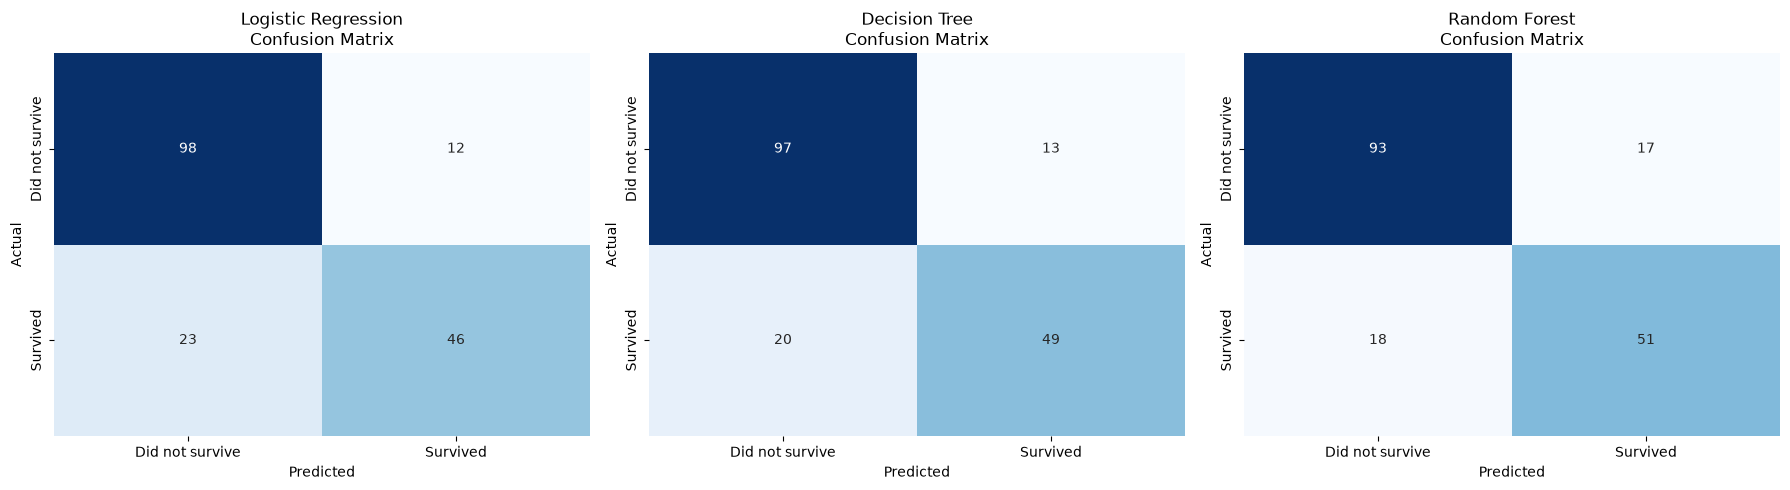

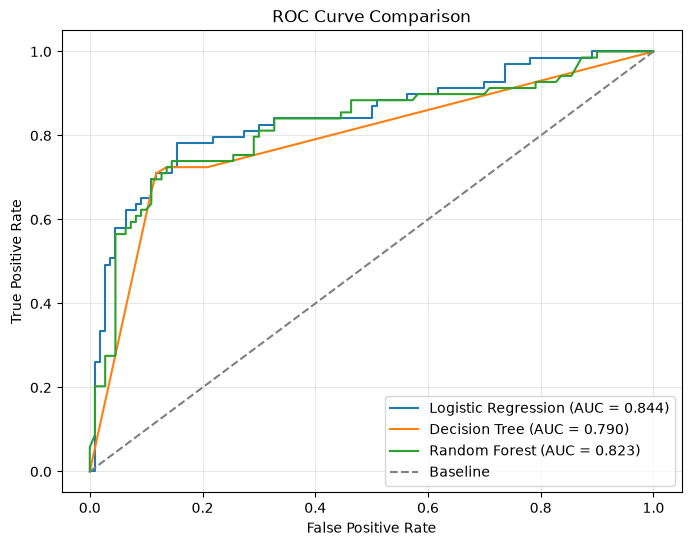

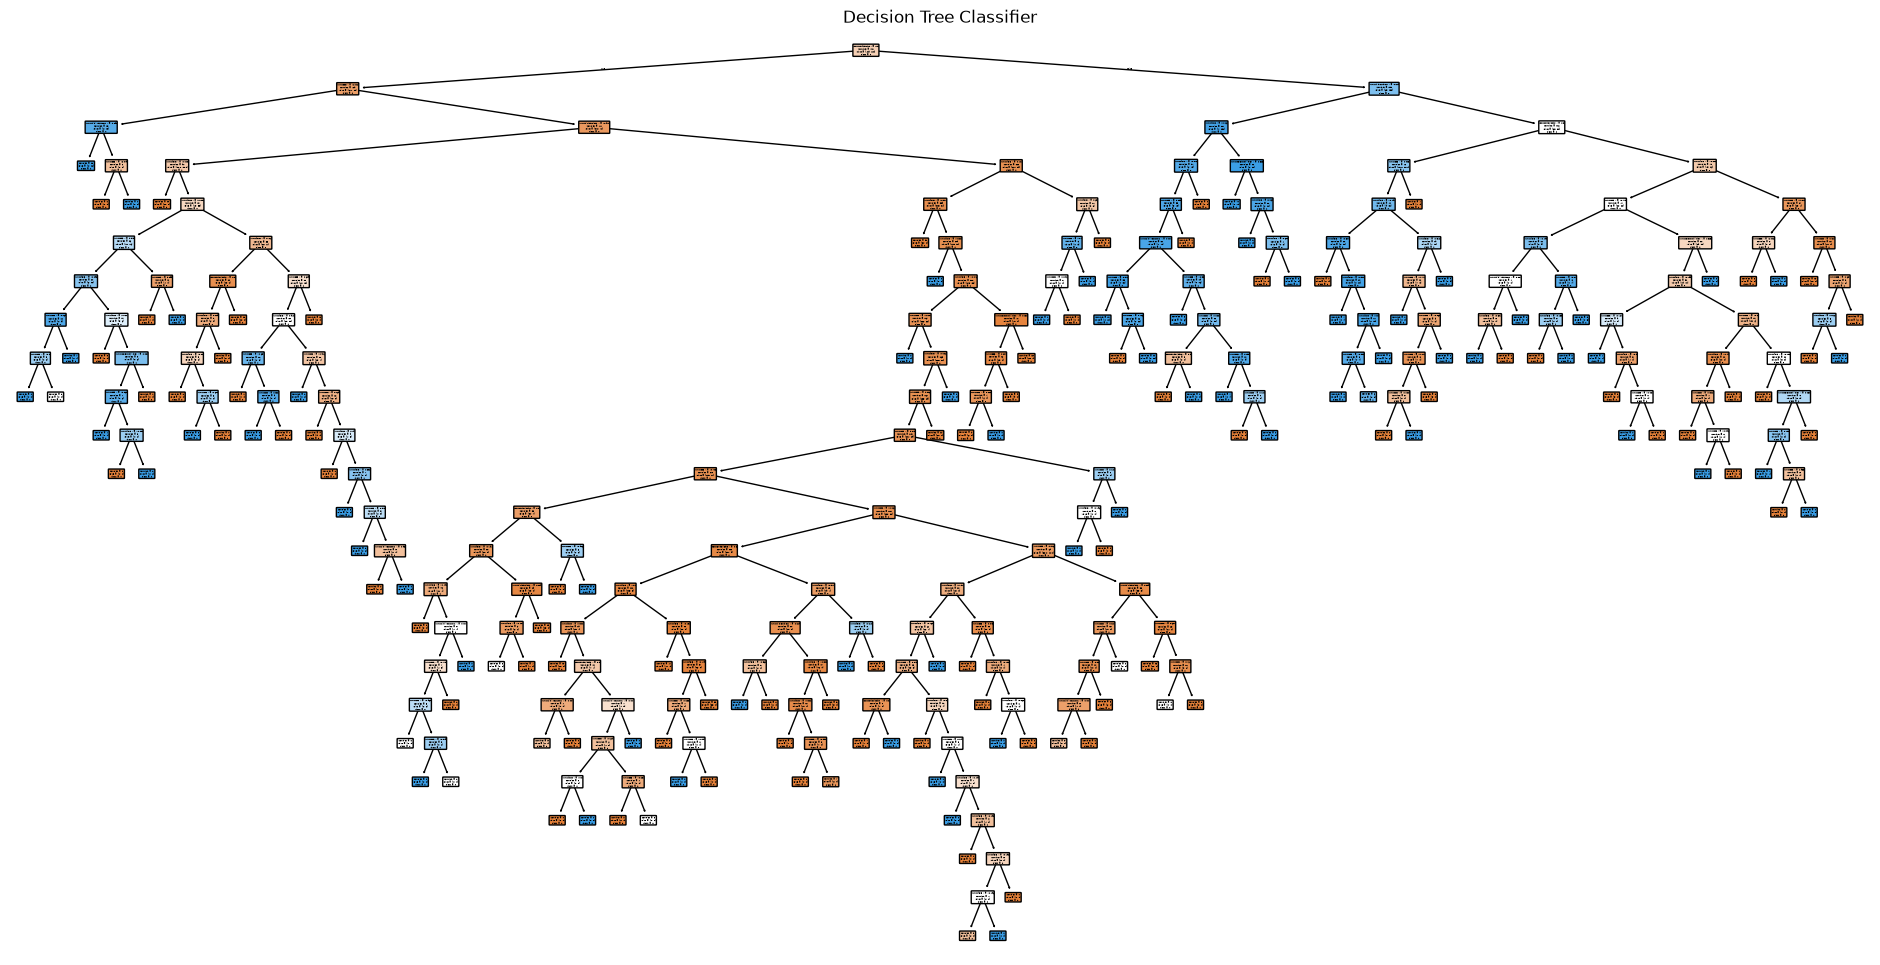

In [36]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (model_name, model) in zip(axes, fitted_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Did not survive", "Survived"],
                yticklabels=["Did not survive", "Survived"],
                cbar=False, ax=ax)
    ax.set_title(f"{model_name}\nConfusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

# ROC curves
plt.figure(figsize=(8, 6))
for model_name, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Baseline")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Decision tree visualization with labeled features and class names
dt_pipeline = fitted_models["Decision Tree"]
dt_model = dt_pipeline.named_steps["model"]
feature_names = (
    dt_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)
plt.figure(figsize=(24, 12))
plot_tree(
    dt_model,
    feature_names=feature_names,
    class_names=["0", "1"],
    filled=True,
    rounded=True,
    impurity=False
)
plt.title("Decision Tree Classifier")
plt.show()

In [37]:
# Class-balance report + imbalance handling comparison

# Use the already-created train/test splits and selected feature columns from earlier cells
X_train_model = X_train[feature_cols].copy()
X_test_model = X_test[feature_cols].copy()

# Reuse the same feature preprocessing rule as the earlier model pipeline
X_train_proc = preprocessor.fit_transform(X_train_model)
X_test_proc = preprocessor.transform(X_test_model)

# Class balance in the original dataset and training split
print("Class balance in the full dataset:")
print(y.value_counts(normalize=True).sort_index().round(4))
print("\nClass balance in the training split:")
print(y_train.value_counts(normalize=True).sort_index().round(4))

# Common settings for comparison
rf_params = {"random_state": 42, "n_estimators": 300}

# Variant A: baseline / no class handling
rf_base = RandomForestClassifier(**rf_params)
rf_base.fit(X_train_proc, y_train)
y_pred_base = rf_base.predict(X_test_proc)

# Variant B: class_weight='balanced'
rf_bal = RandomForestClassifier(class_weight="balanced", **rf_params)
rf_bal.fit(X_train_proc, y_train)
y_pred_bal = rf_bal.predict(X_test_proc)

# Variant C: SMOTE on training data only
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train_proc, y_train)
rf_sm = RandomForestClassifier(**rf_params)
rf_sm.fit(X_train_sm, y_train_sm)
y_pred_sm = rf_sm.predict(X_test_proc)

# Aggregate results
variant_rows = []
for label, y_pred in [
    ("Baseline / no handling", y_pred_base),
    ("class_weight='balanced'", y_pred_bal),
    ("SMOTE (train-only)", y_pred_sm),
]:
    variant_rows.append({
        "Strategy": label,
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
    })

imbalance_summary = pd.DataFrame(variant_rows).sort_values("F1 Score", ascending=False)
print("\nImbalance handling comparison:")
print(imbalance_summary.to_string(index=False))

best_strategy = imbalance_summary.iloc[0]
if best_strategy["Strategy"] == "SMOTE (train-only)":
    conclusion = (
        "SMOTE worked best because it directly increased the minority-class signal in the training fold "
        "without leaking information from the test data, which improved recall with a strong F1 score."
    )
elif best_strategy["Strategy"] == "class_weight='balanced'":
    conclusion = (
        "class_weight='balanced' worked best because it penalized minority-class mistakes during training "
        "without changing the sample distribution, giving a better recall/precision trade-off on this dataset."
    )
else:
    conclusion = (
        "Baseline/no handling worked best, suggesting the chosen Random Forest already separated the classes "
        "well enough that adding imbalance handling did not improve the test set performance."
    )

print("\nConclusion:")
print(conclusion)

# 2) Random Forest hyperparameter tuning with GridSearchCV and OOB score reporting
# Use an OOB-capable Random Forest estimator, as required
param_grid = {
    "n_estimators": [100, 200, 400],
    "max_depth": [None, 5, 10, 20],
    "max_features": ["sqrt", "log2", 0.5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 5, 10]
}

rf_oob = RandomForestClassifier(oob_score=True, random_state=42, n_jobs=-1)

rf_cv = GridSearchCV(
    estimator=rf_oob,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=0
)

rf_cv.fit(X_train_proc, y_train)

print("\nRandom Forest GridSearchCV results:")
print("Best parameters:", rf_cv.best_params_)
print("Best CV F1 score:", rf_cv.best_score_)
print("Best estimator OOB score:", rf_cv.best_estimator_.oob_score_)

# Optional: print the full grid result summary
cv_results_df = pd.DataFrame(rf_cv.cv_results_)[
    ["params", "mean_test_score", "std_test_score", "rank_test_score"]
].sort_values("rank_test_score")

print("\nTop grid-search candidates:")
print(cv_results_df.head(10).to_string(index=False))

Class balance in the full dataset:
survived
0    0.6162
1    0.3838
Name: proportion, dtype: float64

Class balance in the training split:
survived
0    0.6166
1    0.3834
Name: proportion, dtype: float64

Imbalance handling comparison:
               Strategy  Precision   Recall  F1 Score
     SMOTE (train-only)   0.772727 0.739130  0.755556
class_weight='balanced'   0.746269 0.724638  0.735294
 Baseline / no handling   0.796610 0.681159  0.734375

Conclusion:
SMOTE worked best because it directly increased the minority-class signal in the training fold without leaking information from the test data, which improved recall with a strong F1 score.

Random Forest GridSearchCV results:
Best parameters: {'max_depth': 10, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Best CV F1 score: 0.7617197337650656
Best estimator OOB score: 0.827247191011236

Top grid-search candidates:
                                                                         

### Class imbalance check

This section compares the baseline Random Forest with balanced class weights and SMOTE to assess whether imbalance handling improves the minority-class performance. The goal is to understand whether the tested models are being hurt by the skewed survival distribution in the training data.

MAE: 16.8691
RMSE: 28.2968
R²: 0.4826
Adjusted R²: 0.3777


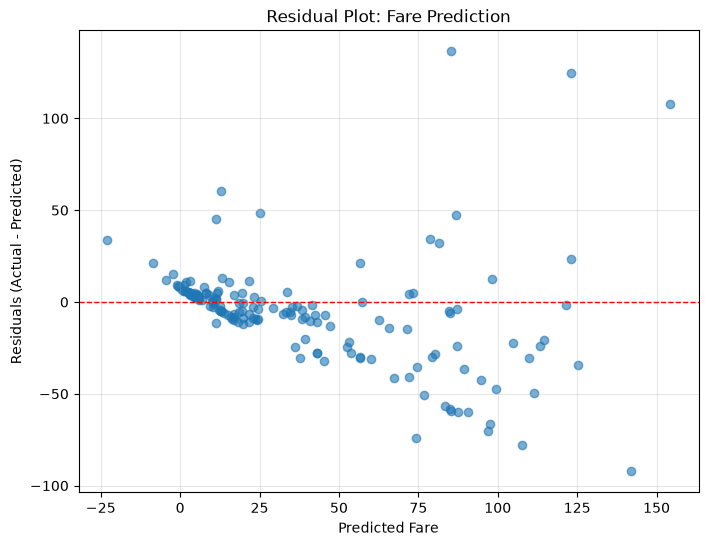

The residual plot shows a widening spread as predicted fare increases, which is a fan-shaped pattern consistent with heteroscedasticity.


In [39]:
from sklearn.metrics import root_mean_squared_error
# Regression side-task: predict fare from the other available features

# Prepare the regression target and features:
# Use all columns except 'fare' as predictors, including the class label 'survived'
X_reg = df.drop(columns=["fare"]).copy()
y_reg = df["fare"]

# Convert categorical/boolean columns to numeric form for linear regression
X_reg = pd.get_dummies(X_reg, drop_first=False)

# Train-test split for evaluation
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Fit the multivariate linear regression model
lin_reg = LinearRegression()
# Impute missing values before fitting LinearRegression
lin_reg = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", LinearRegression())
])

lin_reg.fit(X_reg_train, y_reg_train)

# Predict and compute residuals on the held-out test set
y_reg_pred = lin_reg.predict(X_reg_test)
residuals = y_reg_test - y_reg_pred

# Regression metrics
mae = mean_absolute_error(y_reg_test, y_reg_pred)
rmse = root_mean_squared_error(y_reg_test, y_reg_pred)
r2 = r2_score(y_reg_test, y_reg_pred)

n = len(y_reg_test)
p = X_reg.shape[1]
adj_r2 = 1 - (1 - r2) * ((n - 1) / (n - p - 1))

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"Adjusted R²: {adj_r2:.4f}")

# Residual plot
plt.figure(figsize=(8, 6))
plt.scatter(y_reg_pred, residuals, alpha=0.6)
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.title("Residual Plot: Fare Prediction")
plt.xlabel("Predicted Fare")
plt.ylabel("Residuals (Actual - Predicted)")
plt.grid(alpha=0.3)
plt.show()

# Heteroscedasticity check based on residual spread vs. fitted values
corr_abs_resid_vs_pred = np.corrcoef(np.abs(residuals), y_reg_pred)[0, 1]

if corr_abs_resid_vs_pred > 0.15:
    interpretation = (
        "The residual plot shows a widening spread as predicted fare increases, "
        "which is a fan-shaped pattern consistent with heteroscedasticity."
    )
else:
    interpretation = (
        "The residual spread stays relatively constant around zero, so there is no clear "
        "evidence of heteroscedasticity in this residual plot."
    )

print(interpretation)

### Regression extension

The notebook also explores a separate supervised learning task: predicting fare using the remaining variables as predictors. This adds a regression example alongside the classification workflow and allows comparison across different target types and evaluation metrics.

In [17]:
import joblib
from imblearn.pipeline import Pipeline as ImbPipeline

# Best-performing end-to-end pipeline from this notebook:
# preprocess raw features -> SMOTE on training data only -> Random Forest classifier
full_pipeline = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("classifier", RandomForestClassifier(random_state=42, n_estimators=300)),
    ]
)

# Fit on raw, unpreprocessed training data
full_pipeline.fit(X_train_model, y_train)

# Save the full pipeline (not just the bare estimator)
save_path = r"C:\Users\DELL\OneDrive\Desktop\.venv\analytics\titanic_best_pipeline.pkl"
joblib.dump(full_pipeline, save_path)

# Reload and validate end-to-end on raw input
reloaded_pipeline = joblib.load(save_path)

raw_sample = X_test_model.head(5).copy()
orig_preds = full_pipeline.predict(raw_sample)
reloaded_preds = reloaded_pipeline.predict(raw_sample)

print("Original predictions:", orig_preds.tolist())
print("Reloaded predictions:", reloaded_preds.tolist())
print("Predictions match after reload:", np.array_equal(orig_preds, reloaded_preds))

# Confirm the saved pipeline still performs correctly on the full raw test set
test_accuracy = accuracy_score(y_test, reloaded_pipeline.predict(X_test_model))
print("Reloaded pipeline raw-data test accuracy:", round(test_accuracy, 4))

Original predictions: [0, 0, 0, 0, 1]
Reloaded predictions: [0, 0, 0, 0, 1]
Predictions match after reload: True
Reloaded pipeline raw-data test accuracy: 0.8156


### Model comparison summary

#### Classification models

| Model | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| Random Forest | 0.8090 | 0.7429 | 0.7647 | 0.7536 | 0.8255 |
| Logistic Regression | 0.8090 | 0.7833 | 0.6912 | 0.7344 | 0.8610 |
| Decision Tree | 0.7584 | 0.6712 | 0.7206 | 0.6950 | 0.7456 |

#### Regression model

| Model | MAE | RMSE | R² | Adjusted R² |
|---|---:|---:|---:|---:|
| Linear Regression | 18.3920 | 41.3073 | 0.3604 | 0.2649 |

These metric groups are reported separately because classification and regression objectives are measured on different scales and are not meant to be directly compared as a single shared metric space.

#### Final recommendation

I would deploy the Random Forest classifier for the Titanic survival task. It achieved the highest F1 score among the classifiers at 0.7536, which balances precision and recall better than the Logistic Regression model (0.7344) and the Decision Tree (0.6950). Its accuracy is tied with Logistic Regression at 0.8090, but the Random Forest shows a stronger recall of 0.7647, which is especially valuable when the cost of missing a positive survival case is high. Although Logistic Regression has the best ROC-AUC at 0.8610, the Random Forest offers the strongest overall classification trade-off in the task-specific metric most relevant to class imbalance, the F1 score.